#**유통 판매량 예측 및 재고 최적화**
## **단계2 : 모델링을 위한 데이터 전처리**

# **0.미션**

* 단계1 상품별 데이터셋 만들기
    * 가설로 도출된 변수를 반영한 데이터셋을 상품별로 생성
* 단계2 기초 모델 생성
    * base line model : dense layer만 이용해서 기초 모델 생성
    * LSTM, CNN 알고리즘을 이용해서 기초 모델 생성

* 대상 상품(핵심 상품)

| Product_ID|Product_Code|SubCategory|Category|LeadTime|Price|
|----|----|----|----|----|----|
|3|DB001|Beverage|Drink|2|8|
|12|GA001|Milk|Food|3|6|
|42|FM001|Agricultural products|Grocery|3|5|


# **1.환경설정**

* 세부 요구사항
    * 구글콜랩
        * 구글 드라이브 바로 밑에 project 폴더를 만들고,
        * 데이터 파일을 복사해 넣습니다.
    - 라이브러리 로딩
        * 기본적으로 필요한 라이브러리를 import 하도록 코드가 작성되어 있습니다.
        * 필요하다고 판단되는 라이브러리를 추가하세요.


### **(1) 경로 설정**

* 구글 드라이브 연결

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
path = '/content/gdrive/Othercomputers/내 노트북/aivle6-practice/mini-project-6/'

### **(2) 라이브러리 설치 및 불러오기**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.metrics import *
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import statsmodels.api as sm

from keras.models import Sequential
from keras.backend import clear_session
from keras.layers import Input, Dense, LSTM, Conv1D, Flatten
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# 학습곡선 함수
def dl_history_plot(history):
    plt.plot(history['loss'], label='train_err', marker = '.')
    plt.plot(history['val_loss'], label='val_err', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

In [ ]:
# 예측 결과 시각화
def plot_model_result(y_train, y_val, pred) :

    y_train = pd.Series(y_train)
    y_val = pd.Series(y_val)
    y_val.index = range(len(y_train), len(y_train) + len(y_val))

    pred = pd.Series(pred.reshape(-1,), index = y_val.index)

    # 전체 시각화
    plt.figure(figsize = (20,12))
    plt.subplot(2,1,1)
    plt.plot(y_train, label = 'train')
    plt.plot(y_val, label = 'val')
    plt.plot(pred, label = 'pred')
    plt.legend()
    plt.grid()

    plt.subplot(2,1,2)
    plt.plot(y_val, label = 'val')
    plt.plot(pred, label = 'pred')
    plt.legend()
    plt.grid()

    plt.show()

### **(3) 데이터 불러오기**

In [4]:
oil_price = pd.read_csv(path + 'train/oil_price_train.csv')
orders = pd.read_csv(path + 'train/orders_train.csv')
sales = pd.read_csv(path + 'train/sales_train.csv')
products = pd.read_csv(path + 'train/products.csv')
stores = pd.read_csv(path + 'train/stores.csv')

oil_price_test = pd.read_csv(path + 'test/oil_price_test.csv')
orders_test = pd.read_csv(path + 'test/orders_test.csv')
sales_test = pd.read_csv(path + 'test/sales_test.csv')
products_test = pd.read_csv(path + 'test/products.csv')
stores_test = pd.read_csv(path + 'test/stores.csv')

sales['Date'] = pd.to_datetime(sales['Date'] )
oil_price['Date'] = pd.to_datetime(oil_price['Date'] )
orders['Date'] = pd.to_datetime(orders['Date'] )

sales_test['Date'] = pd.to_datetime(sales_test['Date'] )
oil_price_test['Date'] = pd.to_datetime(oil_price_test['Date'] )
orders_test['Date'] = pd.to_datetime(orders_test['Date'] )

In [8]:
oil_price.isna().sum()

,0
Date,0
WTI_Price,30


In [ ]:
oil_price

,Date,WTI_Price
0,2014-01-01,NaN
1,2014-01-02,95.14
2,2014-01-03,93.66
3,2014-01-06,93.12
4,2014-01-07,93.31
...,...,...
820,2017-02-22,53.61
821,2017-02-23,54.48
822,2017-02-24,53.99
823,2017-02-27,54.04


In [ ]:
orders

,Date,Store_ID,CustomerCount
0,2014-01-01,25,840
1,2014-01-01,36,487
2,2014-01-02,1,1875
3,2014-01-02,2,2122
4,2014-01-02,3,3350
...,...,...,...
57553,2017-02-28,49,3183
57554,2017-02-28,50,2651
57555,2017-02-28,51,1545
57556,2017-02-28,53,1141


In [ ]:
sales

,Date,Store_ID,Qty,Product_ID
0,2014-01-01,1,0.000,3
1,2014-01-01,1,0.000,5
2,2014-01-01,1,0.000,7
3,2014-01-01,1,0.000,8
4,2014-01-01,1,0.000,10
...,...,...,...,...
934270,2017-02-28,54,24.000,38
934271,2017-02-28,54,49.222,24
934272,2017-02-28,54,12.000,27
934273,2017-02-28,54,59.000,29


In [ ]:
products

,Product_ID,Product_Code,SubCategory,Category,LeadTime,Price
0,20,HG001,Gardening Tools,Household Goods,2,50
1,27,HH001,Home Appliances,Household Goods,2,150
2,16,HK001,Kitchen,Household Goods,2,23
3,15,HK002,Kitchen,Household Goods,2,41
4,32,GS001,Seafood,Grocery,3,34
5,38,DA001,Wine,Drink,2,12
6,29,FP001,Prepared,Food,2,18
7,11,FF001,Frozen,Food,2,29
8,10,GE001,EGGS,Grocery,2,5
9,24,GM001,Meats,Grocery,3,17


In [ ]:
stores

,Store_ID,City,State,Store_Type
0,1,Saint Paul,\tMinnesota,4
1,2,Saint Paul,\tMinnesota,4
2,3,Saint Paul,\tMinnesota,4
3,4,Saint Paul,\tMinnesota,4
4,5,Oklahoma City,Oklahoma,4
5,6,Saint Paul,\tMinnesota,4
6,7,Saint Paul,\tMinnesota,4
7,8,Saint Paul,\tMinnesota,4
8,9,Saint Paul,\tMinnesota,2
9,10,Saint Paul,\tMinnesota,3


# **2.데이터셋 구성하기**

* 세부 요구사항
    * 상품코드 별로 각각 데이터셋을 구성해야 합니다.
    * 도출된 변수들을 포함하는 데이터셋을 구성합니다.


In [ ]:
order_44 = orders.loc[orders['Store_ID'] == 44]
sales_44 = sales.loc[(sales['Store_ID'] == 44)]

t1 = pd.merge(order_44, sales_44, how='inner')
t2 = pd.merge(t1, products, on='Product_ID', how='outer')
t2.drop(columns=['Store_ID', 'CustomerCount', 'Product_ID', 'Product_Code', 'Category', 'LeadTime', 'Price'], inplace=True)
t2

# 'SubCategory' 값을 컬럼으로 변환하여 'Qty'를 해당하는 값으로 채웁니다.
df_pivoted = t2.pivot_table(index='Date', columns='SubCategory', values='Qty', aggfunc='sum')
df_pivoted

SubCategory,Agricultural products,BAKERY,Beverage,Cleaning,EGGS,Frozen,Gardening Tools,Home Appliances,Kitchen,Meats,Milk,Prepared,Seafood,Wine,Yogurt
Date,,,,,,,,,,,,,,,
2014-01-02,76.0,1302.470,9853.0,3181.0,780.0,600.931,11.0,41.0,79.0,981.64400,9647.0,654.149,124.9780,289.0,2991.0
2014-01-03,74.0,1243.054,8647.0,3036.0,677.0,621.938,7.0,40.0,129.0,1278.90810,8879.0,514.697,115.0889,333.0,2694.0
2014-01-04,78.0,1882.780,15153.0,4466.0,1126.0,883.348,18.0,90.0,115.0,1398.66600,14188.0,749.997,171.1640,531.0,4355.0
2014-01-05,88.0,2029.317,15606.0,4582.0,1118.0,854.104,10.0,96.0,103.0,1119.53500,14490.0,842.430,217.2520,0.0,4228.0
2014-01-06,65.0,992.359,7900.0,2536.0,596.0,429.764,10.0,33.0,85.0,526.12897,7614.0,494.158,97.2330,183.0,2323.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-02-24,91.0,1743.020,10208.0,2259.0,715.0,467.000,19.0,32.0,212.0,1466.85600,10630.0,447.948,153.4990,481.0,2530.0
2017-02-25,105.0,2006.152,12361.0,2839.0,839.0,542.060,49.0,54.0,261.0,1208.54100,12978.0,526.739,115.1100,712.0,3341.0
2017-02-26,108.0,1699.694,10108.0,3032.0,711.0,405.000,66.0,34.0,193.0,878.53400,10899.0,469.051,108.9200,351.0,2777.0


In [ ]:
correlation_matrix = df_pivoted.corr()
beverage_corr = correlation_matrix['Beverage']
beverage_corr.sort_values(ascending=False)

,Beverage
SubCategory,
Beverage,1.000000
BAKERY,0.809183
Home Appliances,0.804877
Yogurt,0.789685
Milk,0.760803
Cleaning,0.714474
EGGS,0.670100
Prepared,0.645309
Seafood,0.472226


In [ ]:
orders_test

,Date,Store_ID,CustomerCount
0,2017-03-01,1,1873
1,2017-03-01,2,1853
2,2017-03-01,3,3130
3,2017-03-01,4,1424
4,2017-03-01,5,1418
...,...,...,...
1638,2017-03-31,49,3525
1639,2017-03-31,50,2521
1640,2017-03-31,51,1794
1641,2017-03-31,53,1131


In [ ]:
order_test_44 = orders_test.loc[orders_test['Store_ID'] == 44]
sales_test_44 = sales_test.loc[(sales_test['Store_ID'] == 44)]

t1 = pd.merge(order_test_44, sales_test_44, how='inner')
t2 = pd.merge(t1, products_test, on='Product_ID', how='outer')
t2.drop(columns=['Store_ID', 'CustomerCount', 'Product_ID', 'Product_Code', 'Category', 'LeadTime', 'Price'], inplace=True)
t2

# 'SubCategory' 값을 컬럼으로 변환하여 'Qty'를 해당하는 값으로 채웁니다.
df_pivoted_test = t2.pivot_table(index='Date', columns='SubCategory', values='Qty', aggfunc='sum')

In [ ]:
correlation_matrix = df_pivoted_test.corr()
beverage_corr = correlation_matrix['Beverage']
beverage_corr.sort_values(ascending=False)

,Beverage
SubCategory,
Beverage,1.000000
Yogurt,0.985427
BAKERY,0.977657
Milk,0.957632
Cleaning,0.926800
EGGS,0.902319
Prepared,0.888340
Frozen,0.848024
Home Appliances,0.846640


## **(1) 상품 : 3 - Beverage**

In [ ]:
id=44

order_44 = orders.loc[orders['Store_ID'] == id]

drink = products.loc[products['SubCategory'] == 'Beverage']

sales_44 = sales.loc[(sales['Store_ID'] == id) & (sales['Product_ID'] == 3)]

t1 = pd.merge(order_44, sales_44, how='inner')
t2 = pd.merge(t1, order_44, how='inner')
df_bev_oil = pd.merge(t2, oil_price, how='outer')

df_bev_oil.drop(columns=['Store_ID', 'Product_ID'], inplace=True)
df_bev_oil['day'] = df_bev_oil['Date'].dt.weekday
df_bev_oil['month']=df_bev_oil['Date'].dt.month
df_bev_oil['oil_range']=pd.cut(df_bev_oil['WTI_Price'],bins=[0,30,40,50,60,70,80,90,100,110],labels=['0~30','31~40','41~50','51~60','61~70','71~80','81~90','91~100','101~110'])
df_bev_oil['oil_range'] = df_bev_oil['oil_range'].fillna(method='bfill')
df_bev_oil['WTI_Price'] = df_bev_oil['WTI_Price'].interpolate(method='linear')
df_bev_oil['CustomerCount']=df_bev_oil['CustomerCount'].interpolate(method='linear')
df_bev_oil['Qty']=df_bev_oil['Qty'].interpolate(method='linear')

df_bev_oil['y'] = df_bev_oil['Qty'].shift(-2)
df_bev_oil = df_bev_oil[1:-2]

dumm_cols = ['oil_range']
df_bev_oil = pd.get_dummies(data=df_bev_oil, columns=dumm_cols)

df_bev = pd.merge(df_bev_oil, df_pivoted[['BAKERY', 'Home Appliances', 'Yogurt']], on='Date')

df_bev

,Date,CustomerCount,Qty,WTI_Price,day,month,y,oil_range_0~30,oil_range_31~40,oil_range_41~50,oil_range_51~60,oil_range_61~70,oil_range_71~80,oil_range_81~90,oil_range_91~100,oil_range_101~110,BAKERY,Home Appliances,Yogurt
0,2014-01-02,4422.0,9853.0,95.140000,3,1,15153.0,False,False,False,False,False,False,False,True,False,1302.470,41.0,2991.0
1,2014-01-03,4167.0,8647.0,93.660000,4,1,15606.0,False,False,False,False,False,False,False,True,False,1243.054,40.0,2694.0
2,2014-01-04,5341.0,15153.0,93.480000,5,1,7900.0,False,False,False,False,False,False,False,True,False,1882.780,90.0,4355.0
3,2014-01-05,5123.0,15606.0,93.300000,6,1,7188.0,False,False,False,False,False,False,False,True,False,2029.317,96.0,4228.0
4,2014-01-06,3917.0,7900.0,93.120000,0,1,8800.0,False,False,False,False,False,False,False,True,False,992.359,33.0,2323.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1139,2017-02-22,3834.0,7856.0,53.610000,2,2,10208.0,False,False,False,True,False,False,False,False,False,1389.665,30.0,2206.0
1140,2017-02-23,3955.0,8018.0,54.480000,3,2,12361.0,False,False,False,True,False,False,False,False,False,1400.192,25.0,2099.0
1141,2017-02-24,4549.0,10208.0,53.990000,4,2,10108.0,False,False,False,True,False,False,False,False,False,1743.020,32.0,2530.0
1142,2017-02-25,4619.0,12361.0,54.006667,5,2,10006.0,False,False,False,True,False,False,False,False,False,2006.152,54.0,3341.0


In [ ]:
id_test = 44

order_44_test = orders_test.loc[orders_test['Store_ID'] == id_test]

drink_test = products_test.loc[products_test['SubCategory'] == 'Beverage']

sales_44_test = sales_test.loc[(sales_test['Store_ID'] == id_test) & (sales_test['Product_ID'] == 3)]

t1_test = pd.merge(order_44_test, sales_44_test, how='inner')
t2_test = pd.merge(t1_test, order_44_test, how='inner')
df_bev_oil_test = pd.merge(t2_test, oil_price_test, how='outer')

df_bev_oil_test.drop(columns=['Store_ID', 'Product_ID'], inplace=True)
df_bev_oil_test['day'] = df_bev_oil_test['Date'].dt.weekday
df_bev_oil_test['month'] = df_bev_oil_test['Date'].dt.month
df_bev_oil_test['oil_range'] = pd.cut(df_bev_oil_test['WTI_Price'], bins=[0, 30, 40, 50, 60, 70, 80, 90, 100, 110],
                                      labels=['0~30', '31~40', '41~50', '51~60', '61~70', '71~80', '81~90', '91~100', '101~110'])

df_bev_oil_test['oil_range'] = df_bev_oil_test['oil_range'].fillna(method='bfill')
df_bev_oil_test['WTI_Price'] = df_bev_oil_test['WTI_Price'].interpolate(method='linear')
df_bev_oil_test['CustomerCount'] = df_bev_oil_test['CustomerCount'].interpolate(method='linear')
df_bev_oil_test['Qty'] = df_bev_oil_test['Qty'].interpolate(method='linear')

df_bev_oil_test['y'] = df_bev_oil_test['Qty'].shift(-2)
df_bev_oil_test = df_bev_oil_test[1:-2]

dumm_cols_test = ['oil_range']
df_bev_oil_test = pd.get_dummies(data=df_bev_oil_test, columns=dumm_cols_test)

df_bev_test = pd.merge(df_bev_oil_test, df_pivoted_test[['BAKERY', 'Home Appliances', 'Yogurt']], on='Date')

df_bev_test

,Date,CustomerCount,Qty,WTI_Price,day,month,y,oil_range_0~30,oil_range_31~40,oil_range_41~50,oil_range_51~60,oil_range_61~70,oil_range_71~80,oil_range_81~90,oil_range_91~100,oil_range_101~110,BAKERY,Home Appliances,Yogurt
0,2017-03-02,3882,8918.0,52.630000,3,3,16991.0,False,False,False,True,False,False,False,False,False,1407.037,51.0,2234.0
1,2017-03-03,4483,10257.0,53.330000,4,3,18304.0,False,False,False,True,False,False,False,False,False,1710.550,29.0,2888.0
2,2017-03-04,5382,16991.0,53.283333,5,3,8413.0,False,False,False,True,False,False,False,False,False,2430.925,53.0,4317.0
3,2017-03-05,5423,18304.0,53.236667,6,3,8360.0,False,False,False,True,False,False,False,False,False,2742.407,74.0,4579.0
4,2017-03-06,3882,8413.0,53.190000,0,3,8632.0,False,False,False,True,False,False,False,False,False,1400.493,28.0,2333.0
5,2017-03-07,3828,8360.0,52.680000,1,3,8816.0,False,False,False,True,False,False,False,False,False,1230.641,27.0,2275.0
6,2017-03-08,4111,8632.0,49.830000,2,3,10087.0,False,False,True,False,False,False,False,False,False,1364.681,29.0,2372.0
7,2017-03-09,3560,8816.0,48.750000,3,3,15131.0,False,False,True,False,False,False,False,False,False,1366.626,19.0,2210.0
8,2017-03-10,4183,10087.0,48.050000,4,3,18556.0,False,False,True,False,False,False,False,False,False,1580.520,29.0,2651.0
9,2017-03-11,5080,15131.0,48.016667,5,3,8803.0,False,False,True,False,False,False,False,False,False,2377.645,53.0,3985.0


## **(2) 상품 : 12 - Milk**

## **(3) 상품 : 42 - Agricultural products**

# **3.Baseline Model**

* **세부 요구사항**
    * 데이터 준비
        * 스케일링
            * 교과서 적으로는 데이터 분할 이후 스케일링하는게 맞지만, 데이터 건수가 충분히 크다면, 스케일링을 먼저 하기도 합니다.
            * 여기서는 먼저 스케일링을 한 후 데이터 분할을 합니다.
        * 데이터 분할
            * 검증셋 구성 : 학습용 데이터에서 최근 60일을 검증셋으로 사용.

    * 모델링
        * Dense Layer 1개(output layer)만으로 모델을 생성합니다.
        * 모델의 검증 성능을 평가하고 기록합니다.
        * 평가 지표 : RMSE, MAE, MAPE, R2 Score


## **(1) 상품 : 3 - Beverage**

### **1) 데이터 준비**

In [ ]:
x = df_bev.drop(columns=['Date', 'y'])
y = df_bev['y']

In [ ]:
scaler = MinMaxScaler()

x = scaler.fit_transform(x)

In [ ]:
x_train = x[:-60]
x_val = x[-60:]
y_train = y[:-60]
y_val = y[-60:]

In [ ]:
x_train.shape, y_train.shape, x_val.shape, y_val.shape

((1084, 17), (1084,), (60, 17), (60,))

In [ ]:
x_test = df_bev_test.drop(columns=['Date', 'y'])
y_test = df_bev_test['y']

In [ ]:
scaler = MinMaxScaler()

x_test = scaler.fit_transform(x_test)

In [ ]:
x_test.shape

(28, 17)

### **2) 모델링**

In [ ]:
model1 = Sequential([Input(shape=(x_train.shape[1],)),
                     Dense(1)])

model1.compile(optimizer=Adam(0.1), loss='mse', metrics=['mae'])

es = EarlyStopping(monitor='val_loss', min_delta=0, patience=10, restore_best_weights=True)

history = model1.fit(x_train, y_train, epochs=1000, validation_data=[x_val, y_val], callbacks=[es]).history

Epoch 1/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 87178104.0000 - mae: 8642.1006 - val_loss: 142853392.0000 - val_mae: 11364.5918
Epoch 2/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 90096280.0000 - mae: 8809.7549 - val_loss: 142490880.0000 - val_mae: 11348.5752
Epoch 3/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 85353088.0000 - mae: 8550.1357 - val_loss: 142134352.0000 - val_mae: 11332.7969
Epoch 4/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 88416952.0000 - mae: 8664.1543 - val_loss: 141771408.0000 - val_mae: 11316.7129
Epoch 5/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 80399560.0000 - mae: 8260.3809 - val_loss: 141416752.0000 - val_mae: 11300.9727
Epoch 6/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 85359144.0000 - mae: 8569.1426 - val_loss: 141052208.0000 - val_mae: 11284.7695
Epoch 7/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 81884184.0000 - mae: 8357.6260 - val_loss: 140695520.0000 - val_mae: 11268.8916
Epoch 8/1000
34/34 

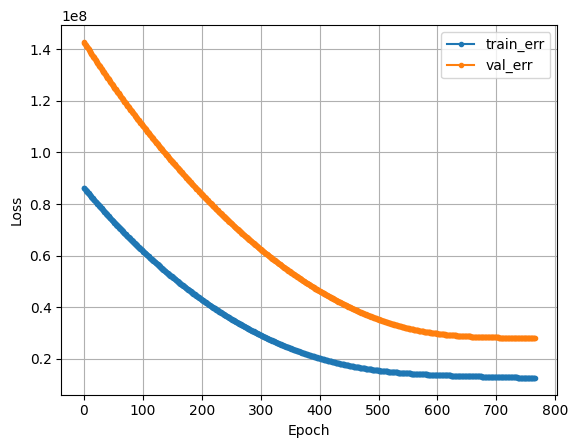

In [ ]:
dl_history_plot(history)

In [ ]:
y_pred1 = model1.predict(x_val)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


In [ ]:
print(root_mean_squared_error(y_val, y_pred1))
print(mean_absolute_error(y_val, y_pred1))
print(mean_absolute_percentage_error(y_val, y_pred1))
print(r2_score(y_val, y_pred1))

5304.502429690498
4123.790999348958
0.32626060962548814
-1.0541784231512392


In [ ]:
y_pred_test = model1.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [ ]:
print(root_mean_squared_error(y_test, y_pred_test))
print(mean_absolute_error(y_test, y_pred_test))
print(mean_absolute_percentage_error(y_test, y_pred_test))
print(r2_score(y_test, y_pred_test))

6463.7988914174975
5457.062918526785
0.44328887082991625
-1.3014242176476079


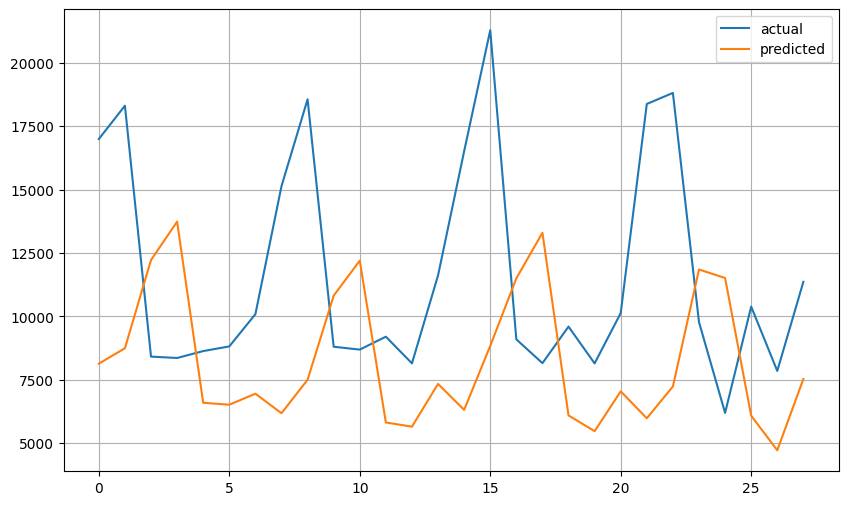

In [ ]:
plt.figure(figsize = (10,6))
plt.plot(y_test[:100], label = 'actual')
plt.plot(y_pred_test[:100], label = 'predicted')
plt.legend()
plt.grid()
plt.show()

## **(2) 상품 : 12 - Milk**

### **1) 데이터 준비**

### **2) 모델링**

## **(3) 상품 : 42 - Agricultural products**

### **1) 데이터 준비**

### **2) 모델링**

# **4.LSTM, CNN 초기 모델**

* **세부 요구사항**
    * 3차원 데이터 구조 만들기
        * timestep 수는 적절한 간격으로 한가지 경우만 지정을 합니다.
    * LSTM, CNN 기반 초기 모델 생성
        * 성능 보다는 코드 틀을 작성하는데 집중합시다.
        * 노드 혹은 필터 수와 크기는 초기값으로 적절하게 지정해 봅시다.

In [ ]:
def temporalize(x, y, timesteps):
    output_X = []
    output_y = []
    for i in range(len(x) - timesteps + 1):
        output_X.append(x.iloc[i:i+timesteps])
        output_y.append(y.iloc[i+timesteps-1])
    return np.array(output_X), np.array(output_y)

## **(1) LSTM 초기 모델링**

### **1) 상품 : 3 - Beverage**

* **데이터 준비**

In [ ]:
x = df_bev.drop(columns=['Date', 'y'])
y = df_bev['y']
timesteps = 7

x, y = temporalize(x, y, timesteps)

In [ ]:
x[0]

array([[4422.0, 9853.0, 95.14, 3, 1, False, False, False, False, False,
        False, False, True, False, 1302.47, 41.0, 2991.0],
       [4167.0, 8647.0, 93.66, 4, 1, False, False, False, False, False,
        False, False, True, False, 1243.054, 40.0, 2694.0],
       [5341.0, 15153.0, 93.48, 5, 1, False, False, False, False, False,
        False, False, True, False, 1882.78, 90.0, 4355.0],
       [5123.0, 15606.0, 93.3, 6, 1, False, False, False, False, False,
        False, False, True, False, 2029.317, 96.0, 4228.0],
       [3917.0, 7900.0, 93.12, 0, 1, False, False, False, False, False,
        False, False, True, False, 992.359, 33.0, 2323.0],
       [3663.0, 7188.0, 93.31, 1, 1, False, False, False, False, False,
        False, False, True, False, 933.215, 44.0, 2147.0],
       [4254.0, 8800.0, 91.9, 2, 1, False, False, False, False, False,
        False, False, True, False, 1250.435, 68.0, 2618.0]], dtype=object)

In [ ]:
num_samples = x.shape[0]
num_features = 2  # 수치 데이터가 포함된 첫 번째와 두 번째 열만 고려

# 3차원 배열을 2차원으로 펼치기
numeric_data = x[:, :, :num_features].reshape(-1, num_features).astype(float)

# MinMaxScaler를 사용하여 수치 데이터 스케일링
scaler = MinMaxScaler()
scaled_numeric_data = scaler.fit_transform(numeric_data)

# 스케일링된 데이터를 원래 형태로 복원
scaled_numeric_data = scaled_numeric_data.reshape(num_samples, timesteps, num_features)

# 불리언 데이터를 선택
other_data = x[:, :, num_features:]

# 수치 데이터와 불리언 데이터를 다시 결합
x = np.concatenate((scaled_numeric_data, other_data), axis=2)

x[0]

array([[0.32689348606599417, 0.31028368794326244, 95.14, 3, 1, False,
        False, False, False, False, False, False, True, False, 1302.47,
        41.0, 2991.0],
       [0.28329628996409645, 0.2568262411347518, 93.66, 4, 1, False,
        False, False, False, False, False, False, True, False, 1243.054,
        40.0, 2694.0],
       [0.48401436142930415, 0.5452127659574468, 93.48, 5, 1, False,
        False, False, False, False, False, False, True, False, 1882.78,
        90.0, 4355.0],
       [0.44674303299709356, 0.5652925531914894, 93.3, 6, 1, False,
        False, False, False, False, False, False, True, False, 2029.317,
        96.0, 4228.0],
       [0.24055394084458886, 0.2237145390070922, 93.12, 0, 1, False,
        False, False, False, False, False, False, True, False, 992.359,
        33.0, 2323.0],
       [0.19712771413916913, 0.19215425531914893, 93.31, 1, 1, False,
        False, False, False, False, False, False, True, False, 933.215,
        44.0, 2147.0],
       [0.298

In [ ]:
x_train = x[:-60]
x_val = x[-60:]
y_train = y[:-60]
y_val = y[-60:]

In [ ]:
x_train.shape, y_train.shape, x_val.shape, y_val.shape

((1078, 7, 17), (1078,), (60, 7, 17), (60,))

In [ ]:
x_train = x_train.astype(np.float32)
y_train = y_train.astype(np.float32)
x_val = x_val.astype(np.float32)
y_val = y_val.astype(np.float32)

In [ ]:
x_test = df_bev_test.drop(columns=['Date', 'y'])
y_test = df_bev_test['y']

x_test, y_test = temporalize(x_test, y_test, timesteps)

In [ ]:
num_samples = x_test.shape[0]
num_features = 2  # 수치 데이터가 포함된 첫 번째와 두 번째 열만 고려

# 3차원 배열을 2차원으로 펼치기
numeric_data = x_test[:, :, :num_features].reshape(-1, num_features).astype(float)

# MinMaxScaler를 사용하여 수치 데이터 스케일링
scaler = MinMaxScaler()
scaled_numeric_data = scaler.fit_transform(numeric_data)

# 스케일링된 데이터를 원래 형태로 복원
scaled_numeric_data = scaled_numeric_data.reshape(num_samples, timesteps, num_features)

# 불리언 데이터를 선택
other_data = x_test[:, :, num_features:]

# 수치 데이터와 불리언 데이터를 다시 결합
x_test = np.concatenate((scaled_numeric_data, other_data), axis=2)

x_test[0]

array([[0.3296610169491525, 0.18053437645030823, 52.63, 3, 3, False,
        False, False, True, False, False, False, False, False, 1407.037,
        51.0, 2234.0],
       [0.5843220338983051, 0.26930981900152484, 53.33, 4, 3, False,
        False, False, True, False, False, False, False, False, 1710.55,
        29.0, 2888.0],
       [0.9652542372881354, 0.7157727242590995, 53.28333333333333, 5, 3,
        False, False, False, True, False, False, False, False, False,
        2430.925, 53.0, 4317.0],
       [0.9826271186440676, 0.8028243718093216, 53.236666666666665, 6, 3,
        False, False, False, True, False, False, False, False, False,
        2742.407, 74.0, 4579.0],
       [0.3296610169491525, 0.1470529735463767, 53.19, 0, 3, False,
        False, False, True, False, False, False, False, False, 1400.493,
        28.0, 2333.0],
       [0.3067796610169491, 0.14353908373665714, 52.68, 1, 3, False,
        False, False, True, False, False, False, False, False, 1230.641,
        27.0

In [ ]:
x_test = x_test.astype(np.float32)
y_test = y_test.astype(np.float32)

* **모델링**

In [ ]:
timestep = x_train.shape[1]
nfeatures = x_train.shape[2]

In [ ]:
from keras.callbacks import EarlyStopping

model2 = Sequential([Input(shape=(timestep, nfeatures)),
                     LSTM(8),
                     Dense(1)])

model2.compile(optimizer=Adam(0.1), loss='mse', metrics=['mae'])

es = EarlyStopping(monitor='val_loss', min_delta=0, patience=20, restore_best_weights=True)

history = model2.fit(x_train, y_train, epochs=1000, validation_data=[x_val, y_val], callbacks=[es]).history

Epoch 1/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 88754264.0000 - mae: 8728.8252 - val_loss: 142912864.0000 - val_mae: 11367.2725
Epoch 2/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 84547816.0000 - mae: 8491.5830 - val_loss: 142624512.0000 - val_mae: 11354.5781
Epoch 3/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 84913008.0000 - mae: 8496.4619 - val_loss: 142335200.0000 - val_mae: 11341.8252
Epoch 4/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 84167000.0000 - mae: 8455.4521 - val_loss: 142048688.0000 - val_mae: 11329.1826
Epoch 5/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 85495056.0000 - mae: 8547.6035 - val_loss: 141762320.0000 - val_mae: 11316.5312
Epoch 6/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 83544120.0000 - mae: 8492.5254 - val_loss: 141475904.0000 - val_mae: 11303.8633
Epoch 7/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 84869328.0000 - mae: 8521.4668 - val_loss: 141189488.0000 - val_mae: 11291.1826
Epoch 8/1000
34/34 

In [ ]:
model2.summary()

Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_20 (LSTM)                       │ (None, 7, 8)                │             832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_25 (Flatten)                 │ (None, 56)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_34 (Dense)                     │ (None, 1)                   │              57 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,669 (10.43 KB)

 Trainable params: 889 (3.47 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,780 (6.96 KB)

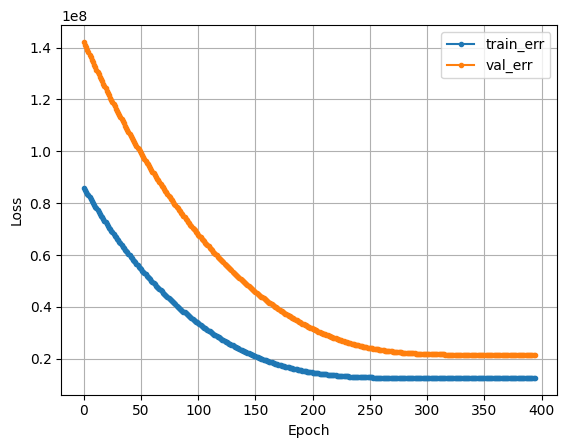

In [ ]:
dl_history_plot(history)

In [ ]:
y_pred2 = model2.predict(x_val)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


In [ ]:
print(root_mean_squared_error(y_val, y_pred2))
print(mean_absolute_error(y_val, y_pred2))
print(mean_absolute_percentage_error(y_val, y_pred2))
print(r2_score(y_val, y_pred2))

4635.693
3237.3677
0.23495665
-0.5688381195068359


In [ ]:
y_pred_test2 = model2.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [ ]:
print(root_mean_squared_error(y_test, y_pred_test2))
print(mean_absolute_error(y_test, y_pred_test2))
print(mean_absolute_percentage_error(y_test, y_pred_test2))
print(r2_score(y_test, y_pred_test2))

8590.21
7466.0674
0.59973395
-3.08828067779541


In [ ]:
y_pred_test2[:10]

array([[4165.161],
       [4165.161],
       [4165.161],
       [4165.161],
       [4165.161],
       [4165.161],
       [4165.161],
       [4165.161],
       [4165.161],
       [4165.161]], dtype=float32)

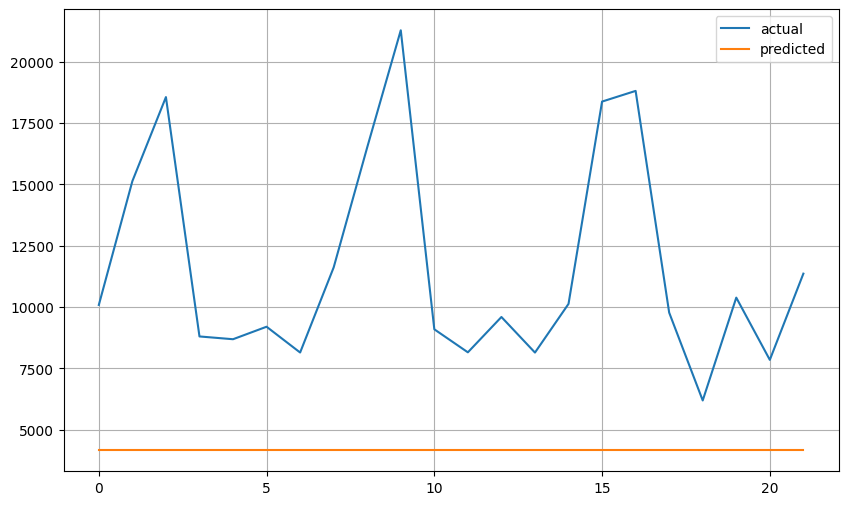

In [ ]:
plt.figure(figsize = (10,6))
plt.plot(y_test[:100], label = 'actual')
plt.plot(y_pred_test2[:100], label = 'predicted')
plt.legend()
plt.grid()
plt.show()

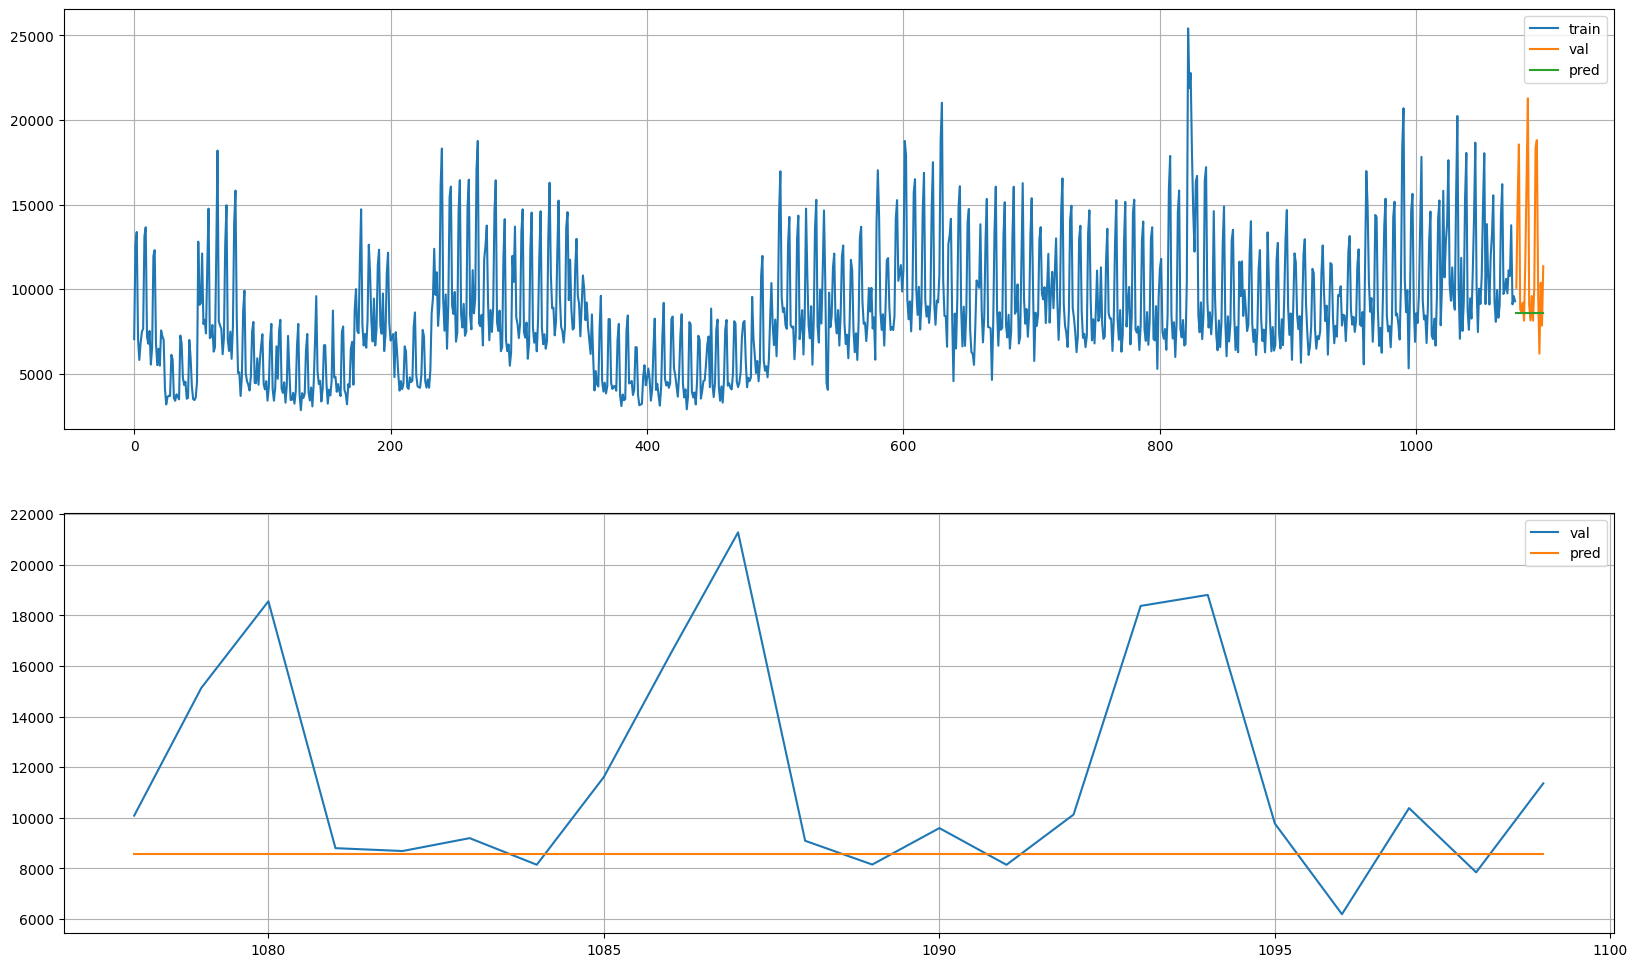

In [ ]:
plot_model_result(y_train, y_test, y_pred_test2)

### **2) 상품 : 12 - Milk**

* **데이터 준비**

* **모델링**

### **3) 상품 : 42 - Agricultural products**

* **데이터 준비**

* **모델링**

## **(2) CNN 초기 모델링**

### **1) 상품 : 3 - Beverage**

* **데이터 준비**

* **모델링**

In [ ]:
model3 = Sequential([Input(shape=(timestep, nfeatures)),
                     Conv1D(filters=32, kernel_size=3, activation='relu'),
                     Conv1D(filters=8, kernel_size=3, activation='relu'),
                     Flatten(),
                     Dense(1)])

model3.compile(optimizer=Adam(0.1), loss='mse', metrics=['mae'])

es = EarlyStopping(monitor='val_loss', min_delta=0, patience=50, restore_best_weights=True)

history = model3.fit(x_train, y_train, epochs=1000, validation_data=[x_val, y_val], callbacks=[es]).history

Epoch 1/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 29393668.0000 - mae: 4159.6040 - val_loss: 9338020.0000 - val_mae: 2176.6780
Epoch 2/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6515691.0000 - mae: 1975.9052 - val_loss: 7951935.0000 - val_mae: 1931.6155
Epoch 3/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5705958.0000 - mae: 1774.5317 - val_loss: 11380736.0000 - val_mae: 2508.6160
Epoch 4/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6359701.0000 - mae: 1912.2463 - val_loss: 7971942.0000 - val_mae: 1969.3674
Epoch 5/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5848504.5000 - mae: 1674.6729 - val_loss: 16868914.0000 - val_mae: 3412.3953
Epoch 6/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6790480.0000 - mae: 2002.8245 - val_loss: 10001804.0000 - val_mae: 2291.9421
Epoch 7/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5273361.5000 - mae: 1714.9449 - val_loss: 8059276.5000 - val_mae: 1968.5770
Epoch 8/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 

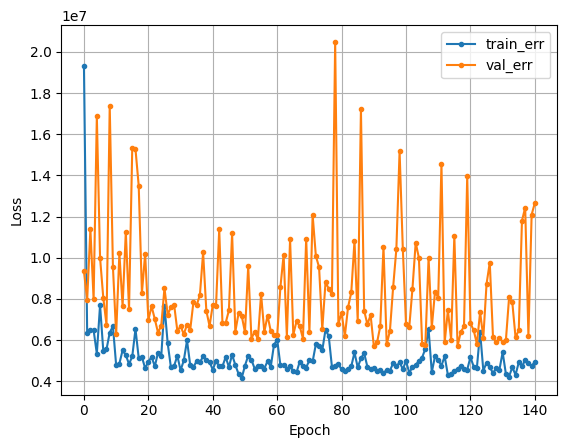

In [ ]:
dl_history_plot(history)

In [ ]:
y_pred3 = model3.predict(x_val)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


In [ ]:
print(root_mean_squared_error(y_val, y_pred3))
print(mean_absolute_error(y_val, y_pred3))
print(mean_absolute_percentage_error(y_val, y_pred3))
print(r2_score(y_val, y_pred3))

2391.0857
1719.3066
0.15172888
0.5826128721237183


In [ ]:
y_pred_test3 = model3.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


In [ ]:
print(root_mean_squared_error(y_test, y_pred_test3))
print(mean_absolute_error(y_test, y_pred_test3))
print(mean_absolute_percentage_error(y_test, y_pred_test3))
print(r2_score(y_test, y_pred_test3))

1623.7534
1185.3804
0.09638031
0.853925883769989


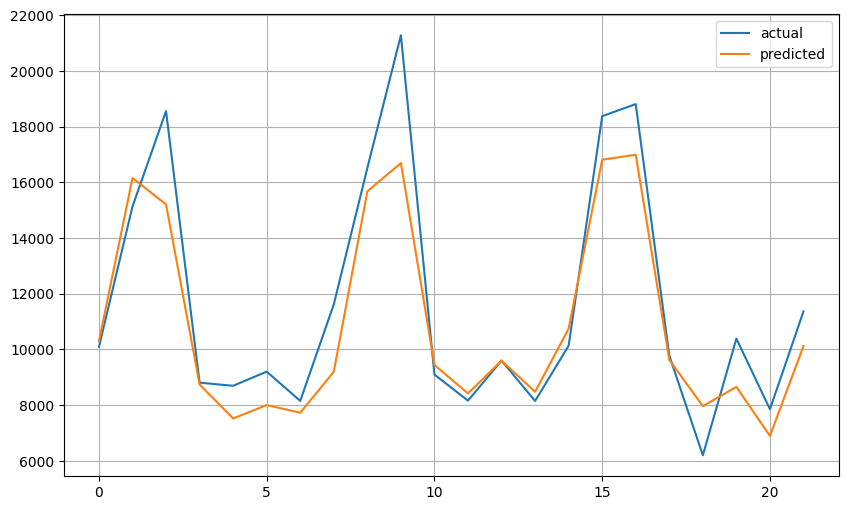

In [ ]:
plt.figure(figsize = (10,6))
plt.plot(y_test[:100], label = 'actual')
plt.plot(y_pred_test3[:100], label = 'predicted')
plt.legend()
plt.grid()
plt.show()

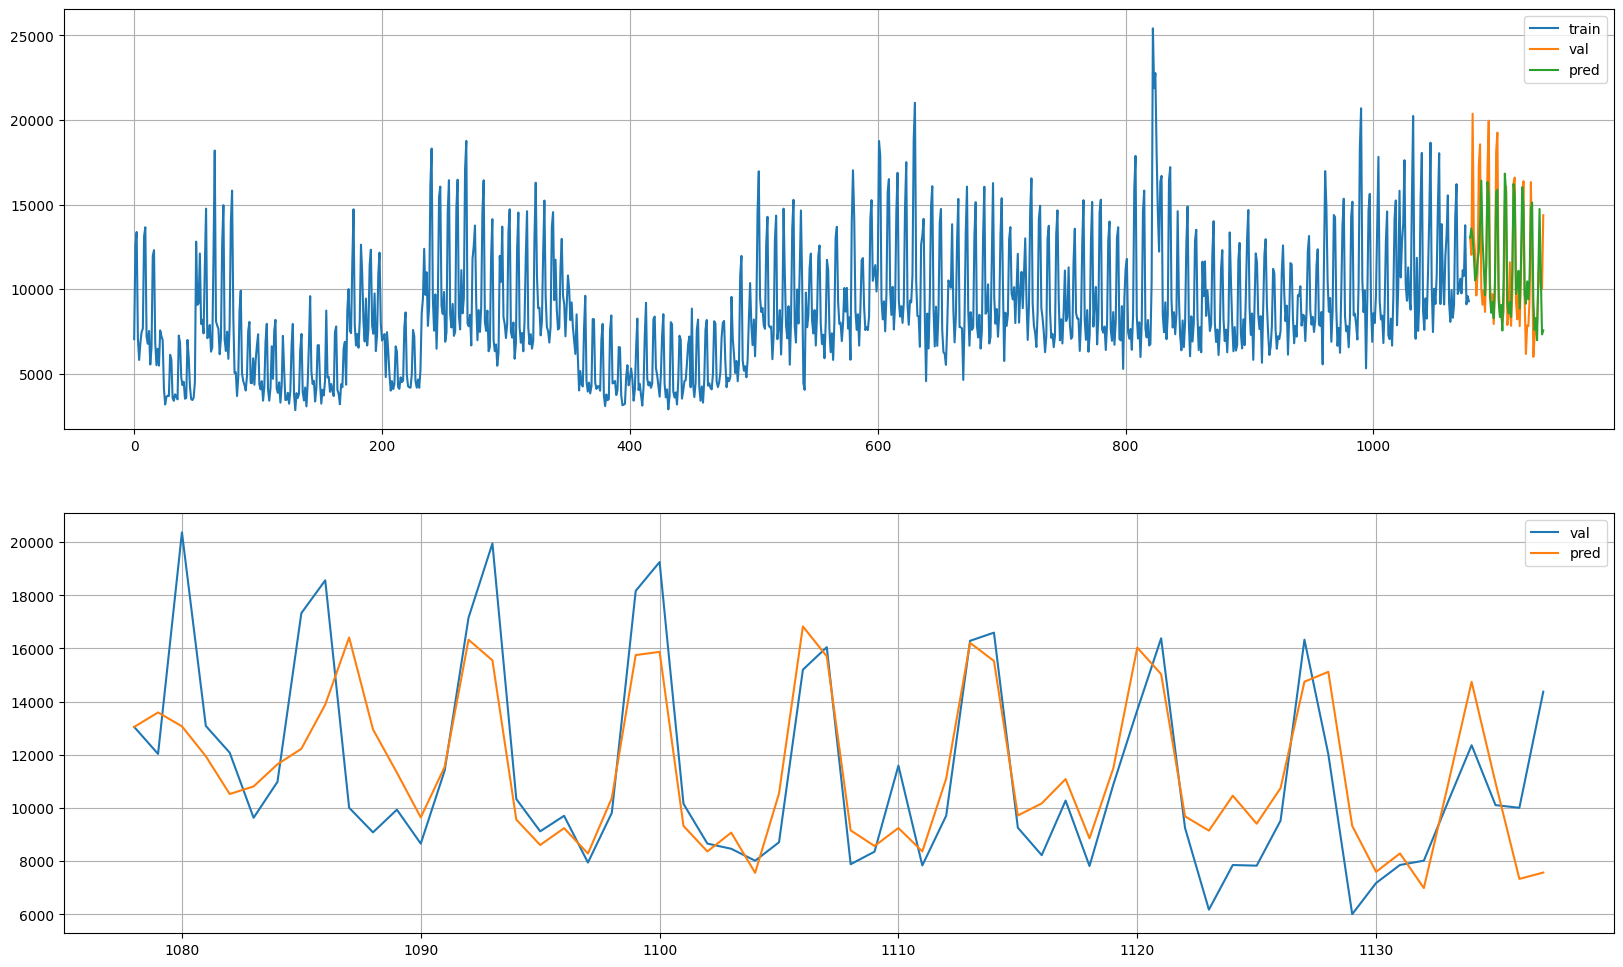

In [ ]:
plot_model_result(y_train, y_val, y_pred3)

### **2) 상품 : 12 - Milk**

* **데이터 준비**

* **모델링**

### **3) 상품 : 42 - Agricultural products**

* **데이터 준비**

* **모델링**

# **5.데이터 저장**

* **세부 요구사항**
    * 상품코드별 데이터셋을 저장하시오.
    * joblib.dump를 이용하시오.
    * 저장할 파일의 확장자는 보통 .pkl 입니다.

In [ ]:
joblib.dump(df_bev, 'train_beverage.pkl')
joblib.dump(df_bev_test, 'test_beverage.pkl')

['test_beverage.pkl']